# investment plots

2021-07-11

See:

-   <https://github.com/matplotlib/mplfinance>
-   <https://github.com/twopirllc/pandas-ta>
-   <https://github.com/twopirllc/pandas-ta/blob/main/examples/example.ipynb>
-   <https://blog.quantinsti.com/calculating-covariance-matrix-portfolio-variance/>

In [1]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import mplfinance as mpf
import pandas_ta as pta

In [2]:
from datetime import datetime
import pytz

## Helper functions

In [3]:
def calc_date_str_from_stooq(x):
    year = np.floor(x['<DATE>'] / 10000)
    month = np.floor((x['<DATE>'] % 10000) / 100)
    day = np.floor((x['<DATE>'] % 100))
    hours = np.floor(x['<TIME>'] / 10000)
#    hours = np.floor(x['<TIME>'] / 10000) - 6.0
    minutes = np.floor((x['<TIME>'] % 10000) / 100)
    seconds = np.floor((x['<TIME>'] % 100))
    s = '%i-%02i-%02i %02i:%02i:%02i' % (year, month, day, hours, minutes, seconds)
    return s

In [4]:
def clean_stooq_df(df):
    _df = df.drop(['<TICKER>', '<PER>', '<OPENINT>'], axis=1)
    _df['Date'] = _df.apply(calc_date_str_from_stooq, axis=1)
    _df['Date'] = pd.to_datetime(_df['Date'])
    _df = _df.drop(['<DATE>', '<TIME>'], axis=1)
    _df = _df.rename(columns={'<OPEN>': 'Open', '<HIGH>': 'High', '<LOW>': 'Low', '<CLOSE>': 'Close', '<VOL>': 'Volume' })
    _df = _df.reindex(columns=['Date', 'Open', 'High', 'Low', 'Close', 'Volume'])
    _df.index = _df['Date']
    _df = _df.drop('Date', axis=1)
    _df['Volume'] = _df['Volume']
    return _df

In [5]:
def calc_metrics(df, metrics):
    if metrics is None:
        metrics = list()
    if 'rsi' in metrics:
        rsi_length = 15
        rsi = pta.rsi(df['Close'], length=rsi_length)
        rsi = rsi - 50.
        df = df.join(rsi)
    if 'smi' in metrics:
        fast = 5
        slow = 20
        signal = 5
        smi = pta.smi(df['Close'], fast=fast, slow=slow, signal=signal)
        smi_key = 'SMIo_%i_%i_%i' % (fast, slow, signal)
        smi_osc = smi[smi_key]*100.
        df = df.join(smi_osc)
    if 'macd' in metrics:
        fast_macd = 5
        slow_macd = 20
        signal_macd = 5
        macd = pta.macd(df['Close'], fast=fast_macd, slow=slow_macd, signal=signal_macd)
        macd_key = 'MACD_%i_%i_%i' % (fast_macd, slow_macd, signal_macd)
        macd_osc = macd[macd_key]
        df = df.join(macd_osc)
    if 'ema' in metrics:
        ema15 = pta.ema(df['Close'], length=15)
        ema60 = pta.ema(df['Close'], length=60)
        df = df.join(ema15)
        df = df.join(ema60)
    if 'stdev' in metrics:
        stdev_length = 15
        stdev = pta.stdev(df['Close'], length=stdev_length)
        df = df.join(stdev)
    if 'zscore' in metrics:
        zscore_length = 60
        zscore = pta.zscore(df['Close'], length=zscore_length)
        df = df.join(zscore)
    return df

In [6]:
def make_addplots(df, metrics):
    addplots = list()
    if metrics is None:
        metrics = list()
    i_panel = 2
    h0 = None
    if 'rsi' in metrics:
        rsi = df['RSI_15']
        h0 = pd.Series([0.]*len(rsi.index), rsi.index)
        addplots.extend([
            mpf.make_addplot(h0, panel=i_panel, type='line', ylabel='RSI',
                             color='gray', linestyle='dashed', width=1, ylim=(-60, 60)),
            mpf.make_addplot(rsi, panel=i_panel, type='line',
                             color='darkorange', secondary_y=False, width=2),
        ])
        i_panel += 1
    if 'smi' in metrics:
        smi_osc = df['SMIo_5_20_5']
        if h0 is None:
            h0 = pd.Series([0.]*len(smi.index), smi.index)
        addplots.extend([
            mpf.make_addplot(h0, panel=i_panel, type='line', ylabel='SMI',
                             color='gray', linestyle='dashed', width=1, ylim=(-60, 60)),
        mpf.make_addplot(smi_osc, panel=i_panel, type='line',
                         secondary_y=False, width=2),
        ])
        i_panel += 1
    if 'macd' in metrics:
        macd_osc = df['MACD_5_20_5']
        if h0 is None:
            h0 = pd.Series([0.]*len(macd_osc.index), macd_osc.index)
        addplots.extend([
            mpf.make_addplot(h0, panel=i_panel, type='line',  ylabel='MACD',
                             color='gray', linestyle='dashed', width=1),
            mpf.make_addplot(macd_osc, panel=i_panel, type='line',
                             color='green', secondary_y=False, width=2),
        ])
        i_panel += 1
    if 'ema' in metrics:
        ema15 = df['EMA_15']
        ema60 = df['EMA_60']
#        if h0 is None:
#            h0 = pd.Series([0.]*len(ema.index), ema.index)
        addplots.extend([
#            mpf.make_addplot(h0, panel=i_panel, type='line',  ylabel='EMA', color='gray', linestyle='dashed', width=1),
            mpf.make_addplot(ema15, panel=i_panel, type='line', ylabel='EMA',
                             color='royalblue', secondary_y=False, width=2),
            mpf.make_addplot(ema60, panel=i_panel, type='line',
                             color='dodgerblue', secondary_y=False, width=2),
        ])
        i_panel += 1
    if 'stdev' in metrics:
        stdev = df['STDEV_15']
        if h0 is None:
            h0 = pd.Series([0.]*len(stdev.index), stdev.index)
        addplots.extend([
            mpf.make_addplot(h0, panel=i_panel, type='line', ylabel='STD',
                             color='gray', linestyle='dashed', width=1),
            mpf.make_addplot(stdev, panel=i_panel, type='line',
                             color='green', secondary_y=False, width=2),
        ])
        i_panel += 1
    if 'zscore' in metrics:
        zscore = df['ZS_60']
        if h0 is None:
            h0 = pd.Series([0.]*len(zscore.index), zscore.index)
        addplots.extend([
            mpf.make_addplot(h0, panel=i_panel, type='line', ylabel='Z',
                             color='gray', linestyle='dashed', width=1),
            mpf.make_addplot(zscore, panel=i_panel, type='line',
                             color='green', secondary_y=False, width=2),
        ])
        i_panel += 1
    return addplots

In [7]:
def plot_candles(df, metrics=None, **kwargs):
    if metrics is None:
        metrics = list()
    df = calc_metrics(df, metrics)
    addplots = make_addplots(df, metrics)
    n_metrics = len(metrics)
    panel_ratios = [1.6, 0.4] + [1]*n_metrics
    figscale = 1.4
    plotargs = dict()
    # initialize plotargs with good defaults
    plotargs['type'] = 'candle'
    plotargs['volume'] = True
    plotargs['style'] = 'charles'
#    if title:
#        plotargs['ylabel'] = title # unique
    plotargs['ylabel_lower'] = 'Vol/'
    plotargs['volume_exponent'] = 3
    plotargs['addplot'] = addplots
    plotargs['panel_ratios'] = panel_ratios
    plotargs['figscale'] = figscale
    plotargs['returnfig'] = True
    # remove kwargs we control
    _kwargs = dict(kwargs)
    title = _kwargs.pop('title', None)
    returnfig = _kwargs.pop('return', False)
    # overwrite plotargs with _kwargs
    plotargs.update(_kwargs)
    fig, axes = mpf.plot(df, **plotargs)
    # clean up the style
    for ax in axes:
        ax.yaxis.set_label_text(ax.yaxis.get_label_text(), {'fontweight': 'normal'})
    if title:
        axes[0].text(0.01, 0.90, title, transform=axes[0].transAxes, fontsize=18)
    if kwargs.get('returnfig'):
        return fig, axes

## Read data from Stooq

https://stooq.com/db/h/

In [8]:
arkw = pd.read_csv('../stooq/daily/us/nyse_etfs/1/arkw.us.txt', skipinitialspace=True)

In [9]:
arkw.head()

,<TICKER>,<PER>,<DATE>,<TIME>,<OPEN>,<HIGH>,<LOW>,<CLOSE>,<VOL>,<OPENINT>
0,ARKW.US,D,20141008,0,16.562,16.867,16.436,16.867,4989,0
1,ARKW.US,D,20141009,0,16.859,16.893,16.580,16.631,19398,0
2,ARKW.US,D,20141010,0,16.292,16.580,16.038,16.038,3940,0
3,ARKW.US,D,20141013,0,15.987,16.055,15.835,16.055,4739,0
4,ARKW.US,D,20141014,0,15.928,15.928,15.818,15.877,6118,0


In [10]:
df = clean_stooq_df(arkw)

In [11]:
df.tail(10)

,Open,High,Low,Close,Volume
Date,,,,,
2021-06-25,152.5713,153.3096,150.370,151.55,978499
2021-06-28,152.7500,155.5100,152.680,155.18,1448746
2021-06-29,155.3900,156.5000,154.400,155.92,945714
2021-06-30,155.2300,155.2300,153.600,154.07,939775
2021-07-01,154.2500,154.3523,150.300,151.26,824447
2021-07-02,152.3700,153.9200,150.400,150.69,1080172
2021-07-06,150.9600,152.1500,149.435,150.73,860041
2021-07-07,151.6100,152.3300,147.395,148.38,853497
2021-07-08,143.6000,147.5700,142.410,146.59,900316


In [12]:
dft = df.tail(200)

In [13]:
dft.head(10)

,Open,High,Low,Close,Volume
Date,,,,,
2020-09-23,106.61,106.8700,102.6400,103.14,477363
2020-09-24,101.26,104.4100,100.4400,103.00,524642
2020-09-25,103.74,106.2364,103.2900,106.00,411249
2020-09-28,108.74,108.7400,106.8200,107.84,596315
2020-09-29,108.06,108.8899,107.4155,108.19,424125
2020-09-30,108.34,109.8200,107.8201,108.60,459713
2020-10-01,110.16,112.1000,109.8715,112.06,747028
2020-10-02,108.84,111.9900,108.7200,110.06,958653
2020-10-05,111.55,112.7000,111.0117,112.57,742999


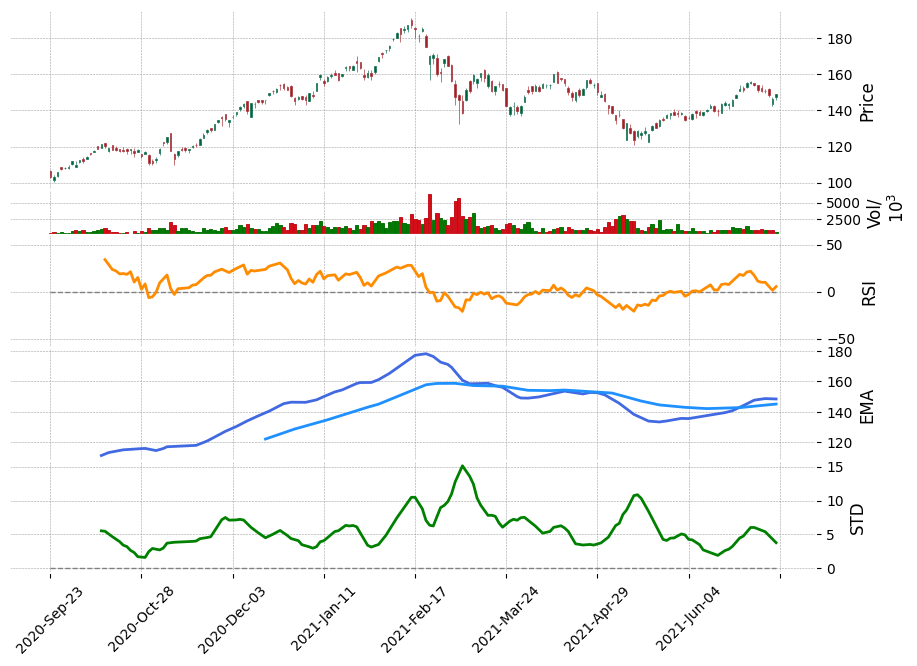

In [14]:
metrics = ['rsi', 'ema', 'stdev']
plot_candles(dft, metrics=metrics)

In [15]:
t1 = datetime(2021, 4, 1, 12, 0, 0)
t2 = datetime(2021, 6, 30, 12, 0, 0)

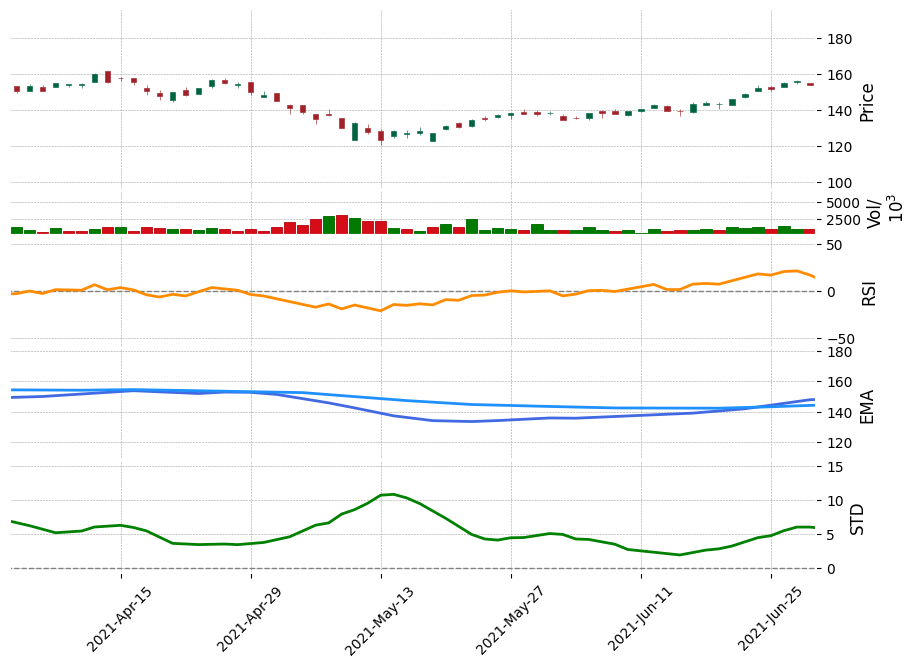

In [16]:
# tight_layout=True, savefig='test.pdf'
metrics = ['rsi', 'ema', 'stdev']
plot_candles(dft, metrics=metrics, xlim=(t1, t2))

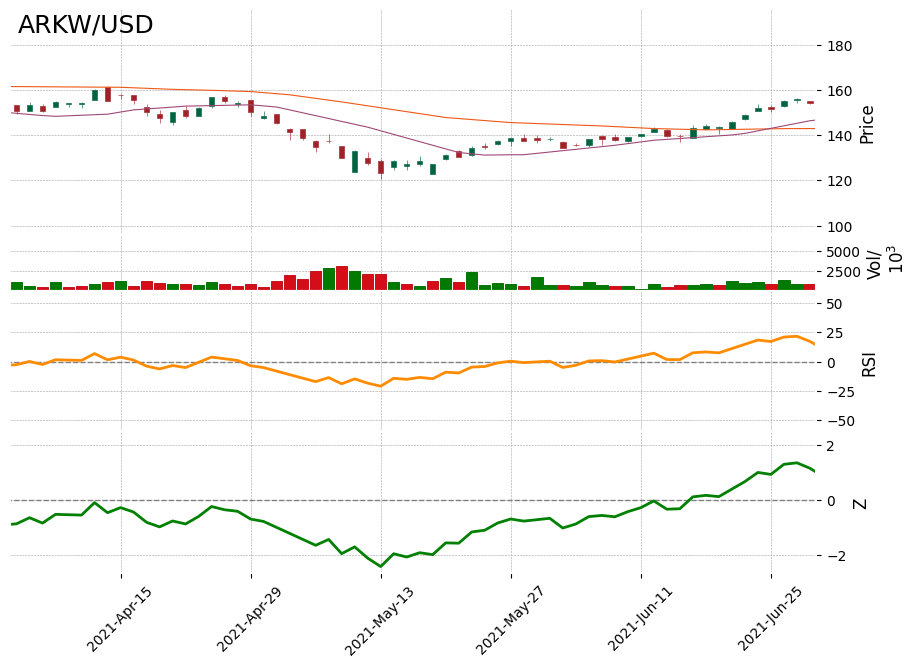

In [17]:
# tight_layout=True, savefig='test.pdf'
#metrics = ['rsi', 'ema', 'stdev', 'zscore']
metrics = ['rsi', 'zscore']
fig, axes = plot_candles(dft, metrics=metrics, title='ARKW/USD', xlim=(t1, t2), mav=(60, 0, 15), returnfig=True)

## Define a portfolio

In [18]:
portfolio_time = datetime(2021, 6, 15, 12, 0, 0)

In [19]:
stocks = pd.read_csv('firstrade-positions-2021-06-15.csv', skipinitialspace=True)
crypto = pd.read_csv('ledger-positions-2021-06-15.csv', skipinitialspace=True)
portfolio = pd.concat([stocks, crypto])
portfolio['cost'] = portfolio['quantity'] * portfolio['unit_cost']
portfolio['market_value'] = portfolio['quantity'] * portfolio['last']
portfolio['percent_gain'] = 100.0*(portfolio['market_value'] - portfolio['cost'])/portfolio['cost']
total_value = float(portfolio['market_value'].sum())
total_cost = float(portfolio['cost'].sum())
total_gain = total_value - total_cost
total_percent_gain = 100.0 * total_gain / total_cost
portfolio['percent_portfolio'] = 100.0*portfolio['market_value']/total_value
portfolio.sort_values(['market_value'], ascending=False, inplace=True, ignore_index=True)

In [20]:
portfolio

,symbol,quantity,unit_cost,last,cost,market_value,percent_gain,percent_portfolio
0,BTC,0.880098,26019.780000,40262.050000,22899.952435,35434.543642,54.736320,18.200459
1,ARKW,225.249830,54.128270,139.610000,12192.383616,31447.128766,157.924371,16.152379
2,ETH,11.273106,1302.680000,2555.150000,14685.249903,28804.477146,96.145638,14.795018
3,IYW,136.481650,52.182440,95.470000,7121.945512,13029.903126,82.954266,6.692628
4,HEX,92275.000000,0.011112,0.091594,1025.393019,8451.879719,724.257583,4.341190
5,LIT,120.124880,42.798290,69.540000,5141.139450,8353.484155,62.483127,4.290651
6,SPHY,269.472850,26.328250,26.690000,7094.748563,7192.230366,1.373999,3.694189
7,MJ,347.911380,14.894620,20.670000,5182.007799,7191.328225,38.774940,3.693725
8,QCLN,100.161130,18.064450,63.090000,1809.355725,6319.165692,249.249493,3.245751
9,GLDM,300.000000,18.392600,18.500000,5517.780000,5550.000000,0.583930,2.850680


In [21]:
print('Portfolio value: $%.1fk' % (total_value/1000.))
print('Portfolio cost:  $%.1fk' % (total_cost/1000.))
print('Unrealized gain:   %.1f%%' % (total_percent_gain))

Portfolio value: $194.7k
Portfolio cost:  $124.5k
Unrealized gain:   56.4%


## Make portfolio timeseries

In [150]:
def add_ticker_dfs(df_tot, df1, shares):
    # Open, High, Low, Close, Volume
    df_tot['Open']   = df_tot['Open']   + (shares*df1['Open'])
    df_tot['High']   = df_tot['High']   + (shares*df1['High'])
    df_tot['Low']    = df_tot['Low']    + (shares*df1['Low'])
    df_tot['Close']  = df_tot['Close']  + (shares*df1['Close'])
    df_tot['Volume'] = df_tot['Volume'] + (shares*df1['Close'])*(df1['Close']*df1['Volume'])
    return df_tot

In [151]:
def correct_portfolio_volume(df):
    df['Volume'] = df['Volume'] / df['Close']
    return df

In [152]:
def make_portfolio_df(ticker_shares_map, ticker_file_map, date_range=None):
    tickers = list(ticker_shares_map.keys())
    tickers.sort()
    if date_range is None:
        date_range = pd.date_range(start='2021-01-04', end='2021-06-30', freq='D')
        df_tot = pd.DataFrame(0, index=date_range, columns=['Open', 'High', 'Low', 'Close', 'Volume'])
        df_tot.index.name = 'Date'
    for ticker in tickers:
        df_ticker = pd.read_csv(ticker_file_map[ticker], skipinitialspace=True)
        df_ticker = clean_stooq_df(df_ticker)
        df_ticker = df_ticker.reindex(df_tot.index, fill_value=0)
        df_ticker.replace(to_replace=0, method='ffill', inplace=True)
        df_tot = add_ticker_dfs(df_tot, df_ticker, ticker_shares_map[ticker])
    df_tot = correct_portfolio_volume(df_tot)
    return df_tot

In [167]:
ticker_shares_map = {
    'ARKW': 225.2,
    'BTC':  0.88,
    'ETH':  11.27,
    'IYW':  136.5,
    'QCLN': 100.2,
}
ticker_file_map = {
    'ARKW': '../stooq/daily/us/nyse_etfs/1/arkw.us.txt',
    'BTC':  '../stooq/daily/world/cryptocurrencies/btc.v.txt',
    'ETH':  '../stooq/daily/world/cryptocurrencies/eth.v.txt',
    'IYW':  '../stooq/daily/us/nyse_etfs/1/iyw.us.txt',
    'QCLN': '../stooq/daily/us/nasdaq_etfs/qcln.us.txt',
}
portfolio_df = make_portfolio_df(ticker_shares_map, ticker_file_map)

In [168]:
portfolio_df

,Open,High,Low,Close,Volume
Date,,,,,
2021-01-04,92494.92680,95059.44540,85665.21954,90413.1917,1.108013e+08
2021-01-05,90164.21440,95649.51020,88505.20030,95241.1706,7.800831e+07
2021-01-06,95033.99990,99100.27750,93232.34860,97393.7432,1.014891e+08
2021-01-07,98543.09998,104983.34070,98152.15454,103787.2072,1.098101e+08
2021-01-08,104930.76778,107705.28142,99495.20580,105551.0985,1.429653e+08
...,...,...,...,...,...
2021-06-26,103233.21466,104333.45092,99762.32720,101812.0308,5.520916e+07
2021-06-27,102129.04476,105615.88262,101463.79000,103729.0021,5.418887e+07
2021-06-28,104126.91210,110757.78160,104059.85950,109962.0472,7.718551e+07


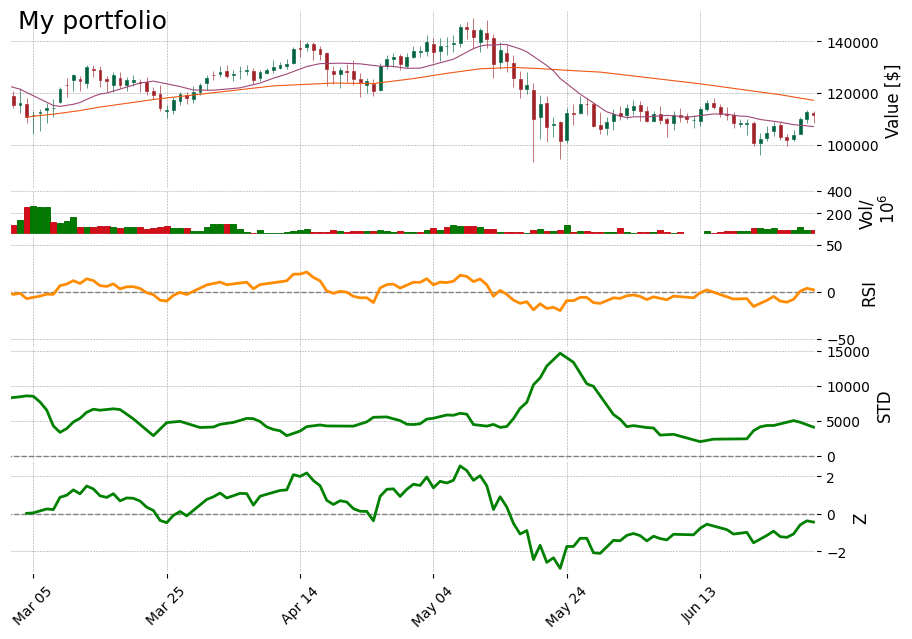

In [170]:
t1 = datetime(2021, 3, 1, 12, 0, 0)
t2 = datetime(2021, 6, 30, 12, 0, 0)
metrics = ['rsi', 'zscore', 'stdev']
plot_candles(portfolio_df, metrics=metrics, title='My portfolio', xlim=(t1, t2), mav=(60, 0, 15), ylabel='Value [$]', volume_exponent=6)

What do I want to do?

